<a href="https://colab.research.google.com/github/Patrick190508/mafia_island_tours/blob/main/notebooks/Regional_Daily_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regional Daily EDA *Ningaloo, Philippines, Gulf of Mexico*

## Step 1 - Load Dataset from Github

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import calendar

url = "https://raw.githubusercontent.com/Patrick190508/whaleshark-mafia-island/main/data/obis_whaleshark_clean_enriched_sites.csv"
db = pd.read_csv(url, low_memory=False)
db['date'] = pd.to_datetime(db['date'])
db['month'] = db['month'].astype(int); db['year'] = db['year'].astype(int)
db['doy'] = db['date'].dt.dayofyear
pd_options = pd.options.display.max_columns = None
print(db.shape)
db.head()

(9731, 29)


,dataset_id,id,occurrenceID,catalogNumber,institutionCode,datasetName,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,date,date_start,date_end,year,month,day,eventTime,bathymetry,shoredistance,sst,sss,flags,is_on_land,uncertainity,sst_cmems,chl_cmems,sss_cmems,ocean,site,doy
0,031dba90-d480-419a-a562-be9a34bc5c49,74b78261-5cb6-4206-9050-8aef7a1a6f16,QLD-Wildnet-6310241,NaN,NaN,NaN,-24.897300,153.272100,100.0,2003-09-09,1.063066e+12,1.063066e+12,2003,9,9.0,NaN,-2.69,59.0,23.89,35.42,[],True,False,21.899993,0.245343,35.634938,Western Pacific,E Australia / New Caledonia,252
1,0820b10a-5710-4e90-b9ed-a2ad7c7ec742,19da48de-f5b6-4941-823f-c5452c2f7077,19978115-release,NaN,IMOS,NaN,-34.960000,118.170000,100.0,2010-07-20,1.279584e+12,1.279584e+12,2010,7,20.0,NaN,-2.00,12.0,19.25,35.58,[],True,False,18.129993,NaN,35.583056,Other,Other,201
2,31677373-22f8-4688-940b-9921d4595bee,5b085b19-befd-40b9-b3ac-1fee69a9b007,CDF:ECOM:140802:WO04:D:7852:11271,NaN,CDF,Biodiversity of Galápagos Marine Reserv,1.383180,-91.811100,NaN,2002-08-14,1.029283e+12,1.029283e+12,2002,8,14.0,NaN,-1.00,32.0,25.63,33.74,[NO_DEPTH],True,False,23.729993,0.174842,34.659871,Eastern Pacific,Galápagos / Panama / Ecuador,226
3,31677373-22f8-4688-940b-9921d4595bee,924bdbb8-a39a-4917-9acc-9c2cf025a692,CDF:ECOM:140618:WO04:D:7852:40365,NaN,CDF,Biodiversity of Galápagos Marine Reserv,1.383180,-91.811100,NaN,2018-06-14,1.528934e+12,1.528934e+12,2018,6,14.0,NaN,-1.00,32.0,25.63,33.74,[NO_DEPTH],True,False,26.979993,0.133131,33.903012,Eastern Pacific,Galápagos / Panama / Ecuador,165
4,7fad32f7-40f3-4134-84a8-beca24103910,66523c33-23d4-4bf3-b560-136e0d4d5225,NaN,SAMS-SHARKS-011624,SAMS,NaN,-34.345001,21.893299,NaN,1994-02-19,7.616160e+11,7.616160e+11,1994,2,19.0,NaN,-2.00,54.0,18.10,35.47,[NO_DEPTH],True,False,NaN,NaN,35.094760,Indian Ocean,South Africa,50


## Step 2 – Define the three peak-season subsets

From this table we can see the percentage of encounters in a certain month related to all the year. The results gives us the high seasons in theese ranges:

*   Ningaloo Reef: April - May - June
*   Philippines: February - March - April - May
*   Gulf of Mexico / Caribbean: April - June - July - August




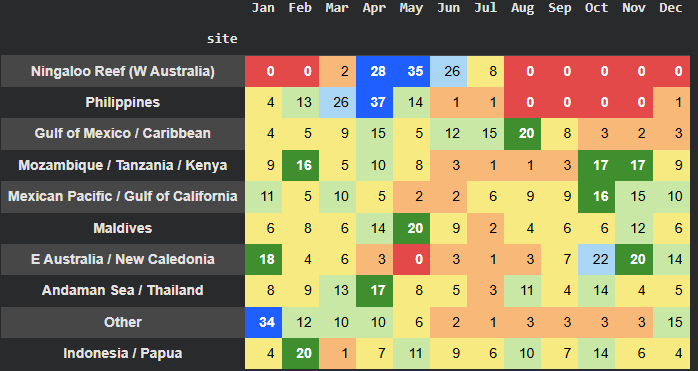

In [7]:
peak_months = {
    "Ningaloo Reef (W Australia)": [4, 5, 6],
    "Philippines":                 [2, 3, 4, 5],
    "Gulf of Mexico / Caribbean":  [6, 7, 8],
}
peak = {sites: db[(db['site'] == sites) & (db['month'].isin(months))].copy() for sites, months in peak_months.items()}
for sites in peak:
    print(f"{sites}: {len(peak[sites])} sightings, {peak[sites]['year'].nunique()} years")

Ningaloo Reef (W Australia): 3544 sightings, 31 years
Philippines: 1924 sightings, 21 years
Gulf of Mexico / Caribbean: 456 sightings, 25 years


## Step 3 – Analysis functions (written once)

Weekly analysis for encounters with values of SST, Chlorophyll-a and SSS taken from encounters records

In [14]:
def season_env_profile(sub, title, var, var_label, color="#e34948"):
    week = (sub['doy'] // 7)
    counts = sub.groupby(week).size()
    env = sub.groupby(week)[var].median()
    labels = [(pd.Timestamp('2001-01-01') + pd.Timedelta(days=int(w*7))).strftime('%d %b') for w in counts.index]

    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.bar(range(len(counts)), counts.values, color="#c8d8ea")
    ax1.set_ylabel("sightings (all years)"); ax1.set_xticks(range(len(counts))); ax1.set_xticklabels(labels, rotation=45)
    ax2 = ax1.twinx()
    ax2.plot(range(len(env)), env.values, color=color, marker="o")
    ax2.set_ylabel(var_label, color=color)
    plt.title(f"{title} — weekly sightings and {var_label}")
    plt.show()

Function for the analysis of the env. variables


In [20]:
centres = {
    "Ningaloo Reef (W Australia)": (-21.90, 113.85),
    "Philippines":                 ( 12.80, 123.60),
    "Gulf of Mexico / Caribbean":  ( 21.50, -86.80),
}

In [25]:
base = "https://raw.githubusercontent.com/Patrick190508/whaleshark-mafia-island/main/data/"
series = {s: pd.read_csv(base + f"daily_{s.split()[0].lower()}.csv", parse_dates=['date']) for s in peak_months}
for s in series: print(s, series[s].shape)

Ningaloo Reef (W Australia) (16418, 8)
Philippines (16418, 8)
Gulf of Mexico / Caribbean (16418, 8)


In [26]:
def annual_profile(s):
    d = series[s]; m = peak_months[s]
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    for ax, var, lab, col in zip(axes, ['sst', 'chl', 'sss'], ['SST (°C)', 'chl-a (mg/m³)', 'salinity (PSU)'], ["#e34948", "#3f8f2f", "#8a4fbf"]):
        q = d.groupby('doy')[var].quantile([0.25, 0.5, 0.75]).unstack()
        ax.fill_between(q.index, q[0.25], q[0.75], color=col, alpha=0.2)
        ax.plot(q.index, q[0.5], color=col)
        ax.axvspan(pd.Timestamp(2001, m[0], 1).dayofyear, pd.Timestamp(2001, m[-1], 28).dayofyear, color="grey", alpha=0.15)
        ax.set_ylabel(lab); ax.grid(alpha=0.3)
    axes[0].set_title(f"{s} — daily climatology (median and interquartile band, all years); grey = peak season")
    axes[-1].set_xlabel("day of year"); plt.show()

In [27]:
def anomaly_table(s):
    d = series[s].copy()
    for v in ['sst', 'chl', 'sss']:
        clim = d.groupby('doy')[v].transform('median')
        d[v + '_anom'] = d[v] - clim
    d = d[d['month'].isin(peak_months[s])]
    grp = d.groupby(d['sightings'] > 0)[['sst_anom', 'chl_anom', 'sss_anom']].agg(['mean', 'std']).round(3)
    grp.index = ['days without sightings', 'days with sightings']
    grp['n_days'] = d.groupby(d['sightings'] > 0).size().values
    return grp

In [28]:
def season_by_year(s):
    d = series[s]; d = d[d['month'].isin(peak_months[s])]
    rows = []
    for y, g in d.groupby('year'):
        n = g['sightings'].sum()
        if n == 0: continue
        w = g.set_index('doy')['sightings'].rolling(7, center=True, min_periods=1).sum()
        rows.append({'year': y, 'sightings': int(n), 'peak_doy': int(w.idxmax()),
                     'sst': g['sst'].mean(), 'chl': g['chl'].mean(), 'sss': g['sss'].mean()})
    return pd.DataFrame(rows).round(2)

def peak_vs_var(s, var, label):
    t = season_by_year(s); t = t[t['sightings'] >= 20]
    plt.figure(figsize=(6, 5))
    plt.scatter(t[var], t['peak_doy'], color="#e34948")
    for _, r in t.iterrows(): plt.annotate(int(r['year']), (r[var], r['peak_doy']), fontsize=8, alpha=0.7)
    plt.xlabel(f"season mean {label}"); plt.ylabel("day of year of peak sightings")
    plt.title(f"{s} — timing of the peak vs {label}"); plt.grid(alpha=0.3); plt.show()
    print("correlation:", round(t[var].corr(t['peak_doy']), 2), "| years:", len(t))

## Step 4 – Daily EDA

### 4.1) Ningaloo Reef – peak season

In [30]:
s = "Ningaloo Reef (W Australia)"

#### Environmental var analysis

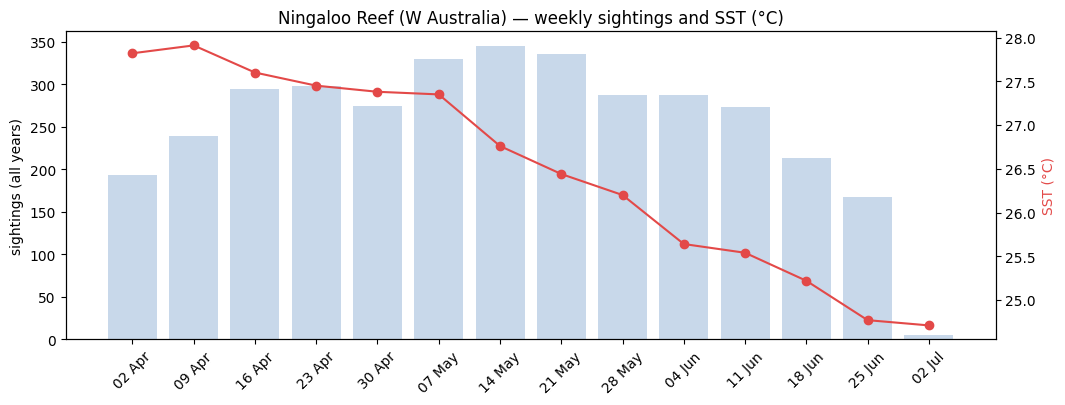

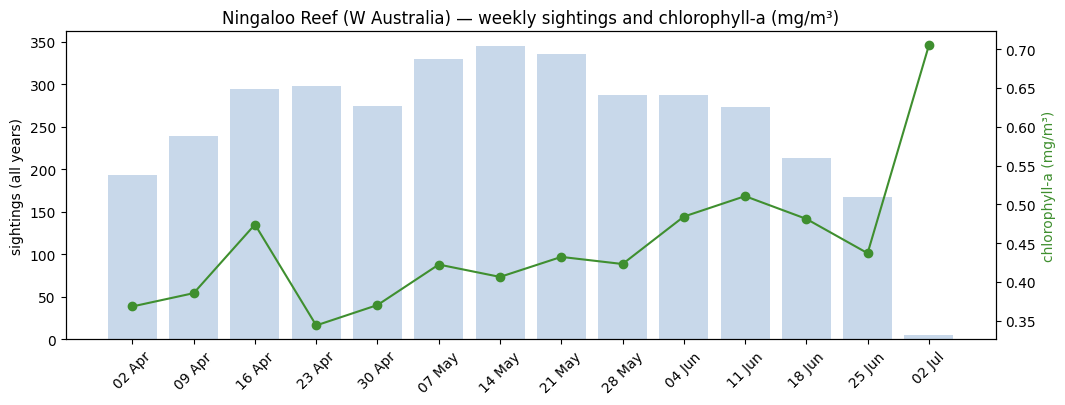

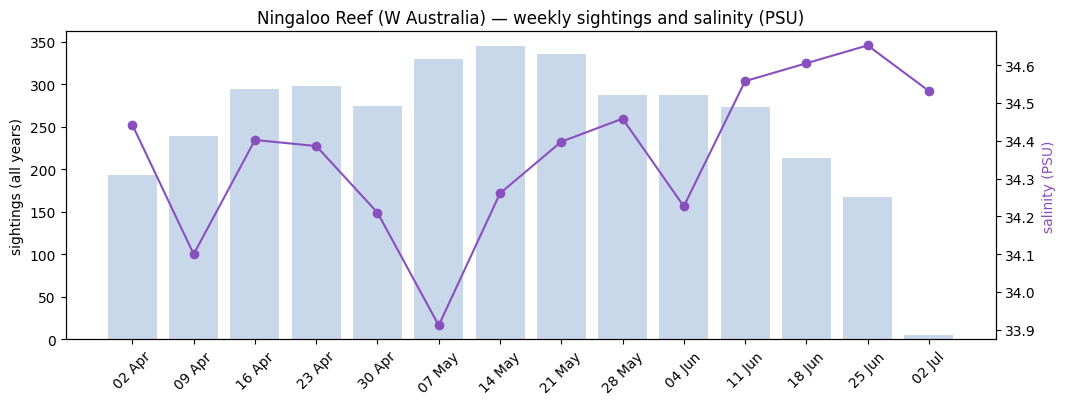

In [17]:
season_env_profile(peak['Ningaloo Reef (W Australia)'], 'Ningaloo Reef (W Australia)', 'sst_cmems', 'SST (°C)')
season_env_profile(peak['Ningaloo Reef (W Australia)'], 'Ningaloo Reef (W Australia)', 'chl_cmems', 'chlorophyll-a (mg/m³)', color="#3f8f2f")
season_env_profile(peak['Ningaloo Reef (W Australia)'], 'Ningaloo Reef (W Australia)', 'sss_cmems', 'salinity (PSU)', color="#8a4fbf")

**SST:** Linearly decreasing over the season, season ends when SST goes below 25°C - Peak at 26.8°C

**Chlorophyll-a:** Low values for all the season and when the season ends there is a peak

**SSS:** No specific pattern in salinity

#### Annual Climatology

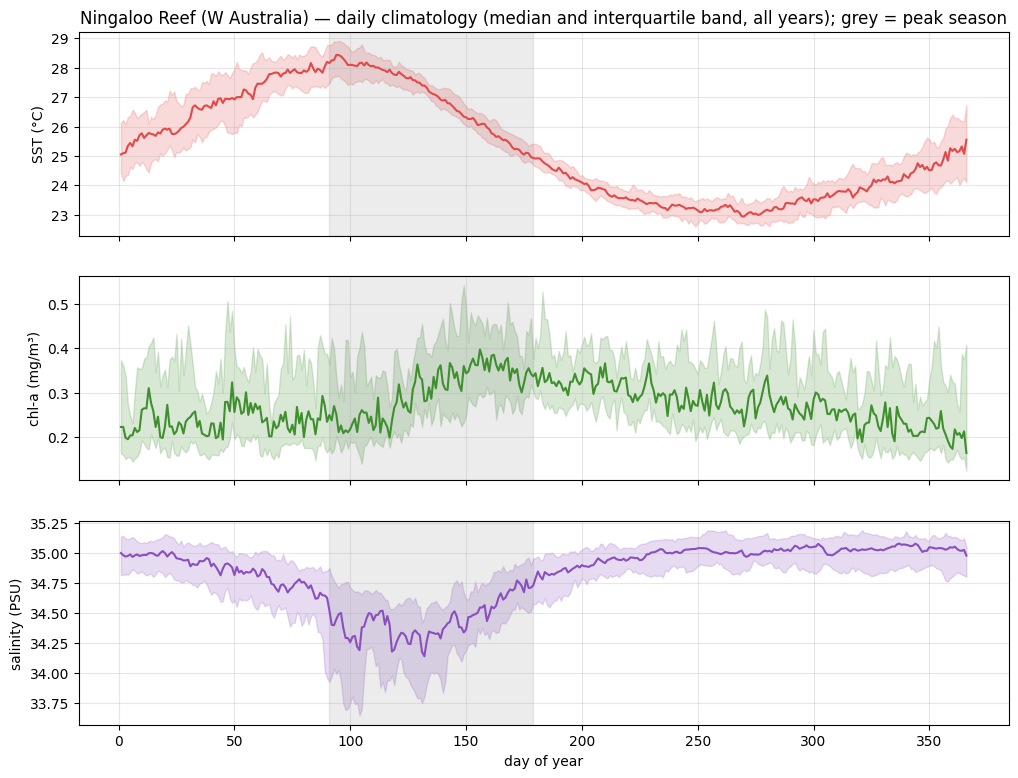

In [31]:
annual_profile(s)

#### Days with vs without sightings (anomalies from the daily climatology, peak season only)

In [32]:
anomaly_table(s)

sst_anom        chl_anom        sss_anom        n_days
                           mean    std     mean    std     mean    std       
days without sightings   -0.007  0.655    0.041  0.169   -0.055  0.508   3236
days with sightings      -0.001  0.576    0.040  0.183   -0.190  0.557    859

#### Season by Season

In [33]:
season_by_year(s)

,year,sightings,peak_doy,sst,chl,sss
0,1986,1,133,26.51,NaN,NaN
1,1992,9,104,26.17,NaN,NaN
2,1994,3,103,26.98,NaN,34.61
3,1995,23,160,26.59,NaN,34.40
4,1996,56,95,26.90,NaN,34.36
5,1997,35,115,26.76,NaN,34.54
6,1998,35,125,27.89,0.23,34.33
7,1999,125,133,27.48,0.35,33.46
8,2000,48,134,26.85,0.32,33.65
9,2001,114,156,26.98,0.33,33.55


#### Timing of the peak vs season conditions

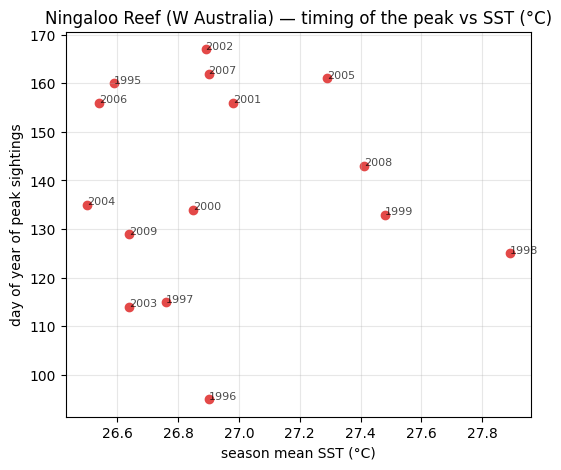

correlation: -0.03 | years: 15


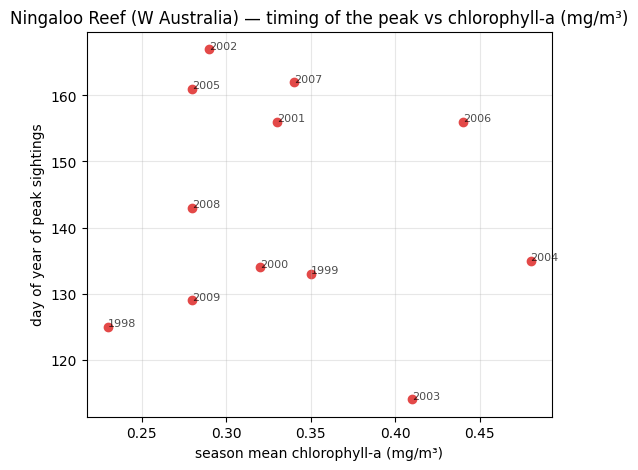

correlation: -0.1 | years: 15


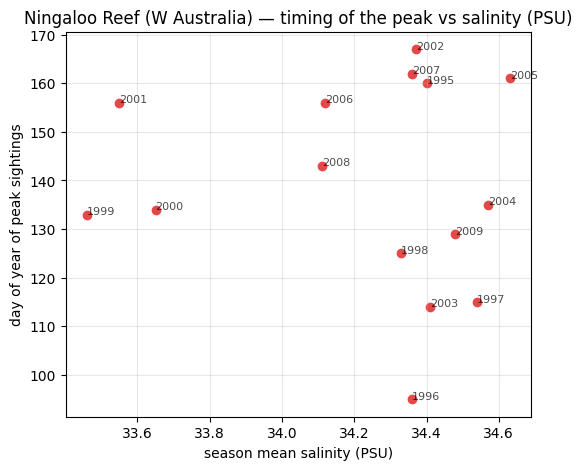

correlation: -0.09 | years: 15


In [34]:
for var, lab in [('sst', 'SST (°C)'), ('chl', 'chlorophyll-a (mg/m³)'), ('sss', 'salinity (PSU)')]:
    peak_vs_var(s, var, lab)

### 4.2) Philippines – peak season

In [35]:
s = "Philippines"

#### Environmental var analysis

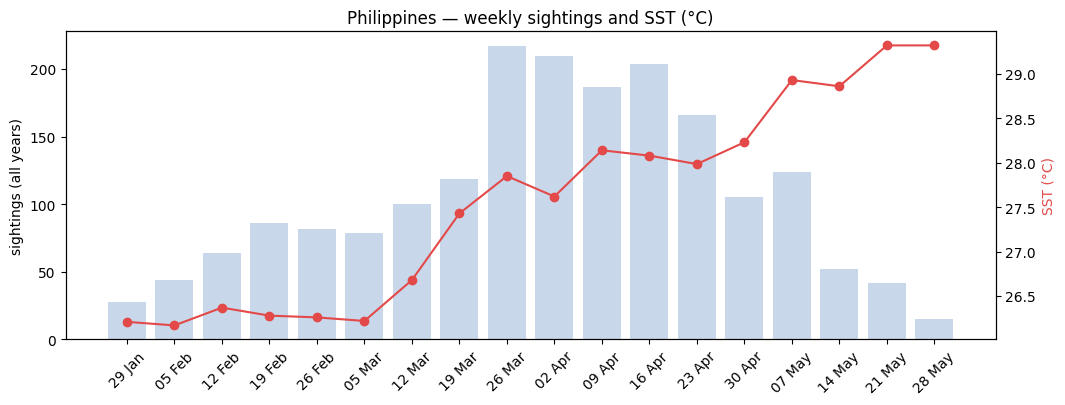

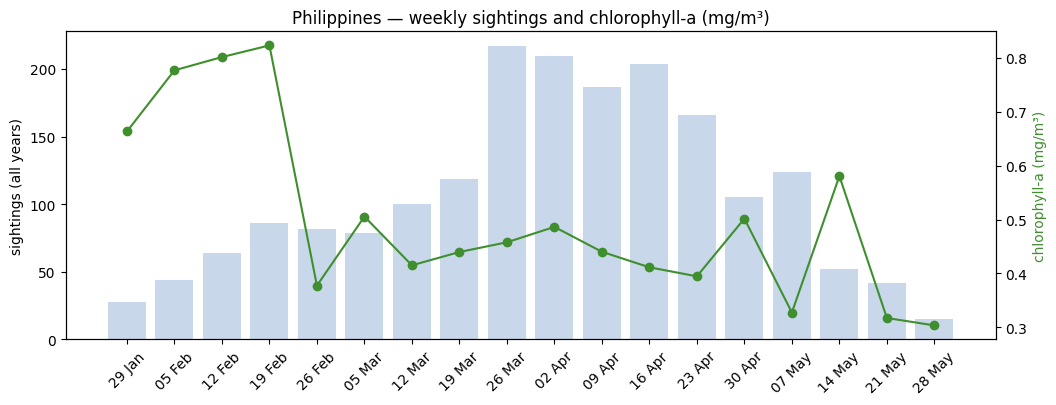

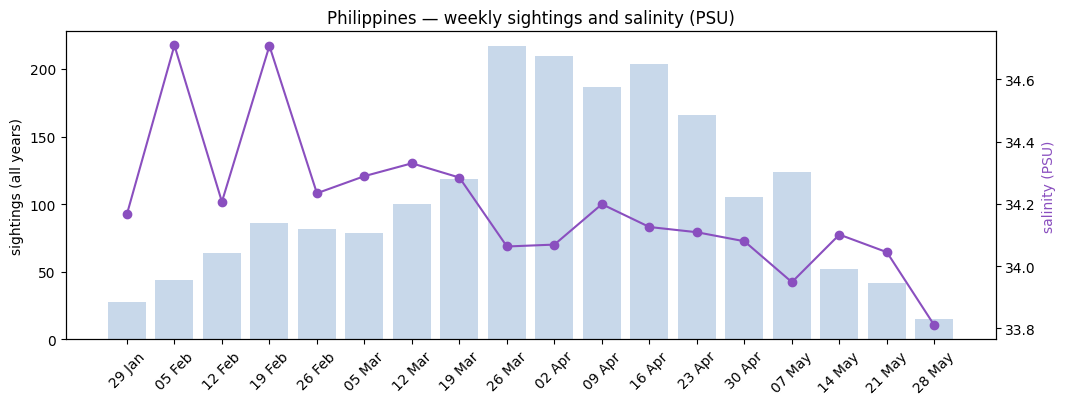

In [36]:
season_env_profile(peak['Philippines'], 'Philippines', 'sst_cmems', 'SST (°C)')
season_env_profile(peak['Philippines'], 'Philippines', 'chl_cmems', 'chlorophyll-a (mg/m³)', color="#3f8f2f")
season_env_profile(peak['Philippines'], 'Philippines', 'sss_cmems', 'salinity (PSU)', color="#8a4fbf")

**SST:** Linearly increasing over the season, season ends when SST goes over 28.5°C - Peak at 27.9°C

**Chlorophyll-a:** High values before the season start, low values during the high season, peak when the season in near to its end (14 may week)

**SSS:** no visible patterns

#### Annual Climatology

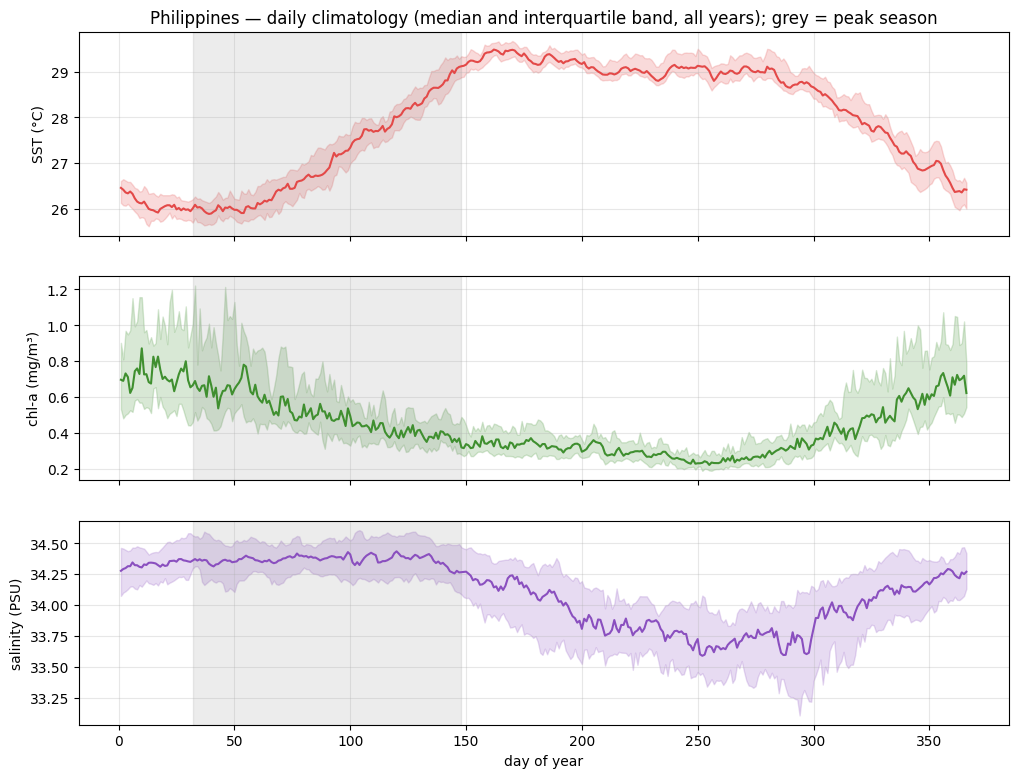

In [37]:
annual_profile(s)

#### Days with vs without sightings (anomalies from the daily climatology, peak season only)

In [38]:
anomaly_table(s)

sst_anom        chl_anom        sss_anom        n_days
                           mean    std     mean    std     mean    std       
days without sightings   -0.005  0.518    0.082  0.348   -0.003  0.241   5047
days with sightings       0.302  0.481    0.049  0.272   -0.102  0.260    364

#### Season by Season

In [39]:
season_by_year(s)

,year,sightings,peak_doy,sst,chl,sss
0,1999,1,72,27.56,0.51,34.33
1,2003,4,73,26.75,0.58,34.67
2,2004,10,73,27.38,0.80,34.31
3,2005,14,111,26.93,0.62,34.45
4,2006,155,94,27.38,0.60,34.18
5,2007,218,112,27.38,0.50,34.40
6,2008,597,88,27.55,0.63,33.99
7,2009,739,85,27.60,0.45,34.18
8,2010,130,51,27.20,0.70,34.66
9,2012,2,34,27.72,0.38,34.06


#### Timing of the peak vs season conditions

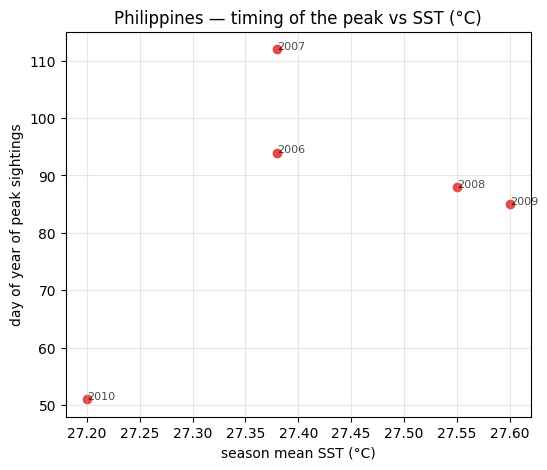

correlation: 0.46 | years: 5


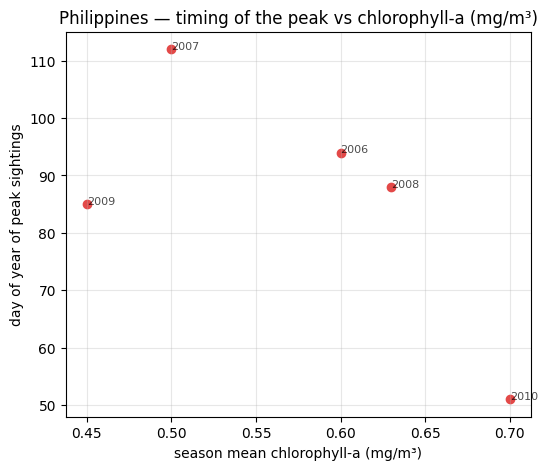

correlation: -0.66 | years: 5


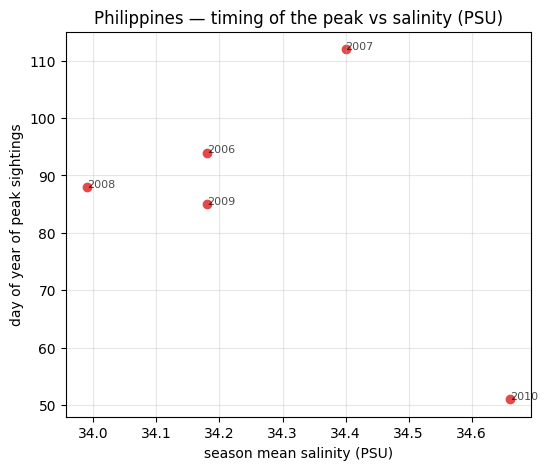

correlation: -0.5 | years: 5


In [40]:
for var, lab in [('sst', 'SST (°C)'), ('chl', 'chlorophyll-a (mg/m³)'), ('sss', 'salinity (PSU)')]:
    peak_vs_var(s, var, lab)

### 4.3) Gulf of Mexico / Caribbean – peak season

In [41]:
s = "Gulf of Mexico / Caribbean"

#### Environmental var analysis

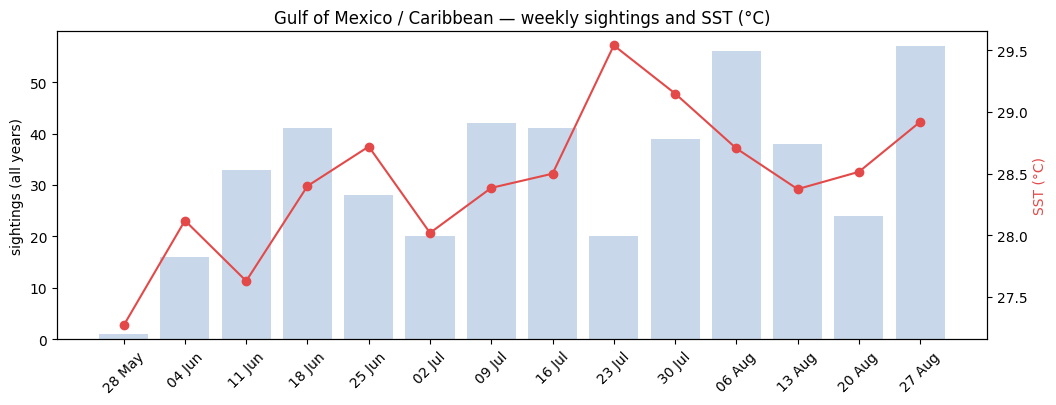

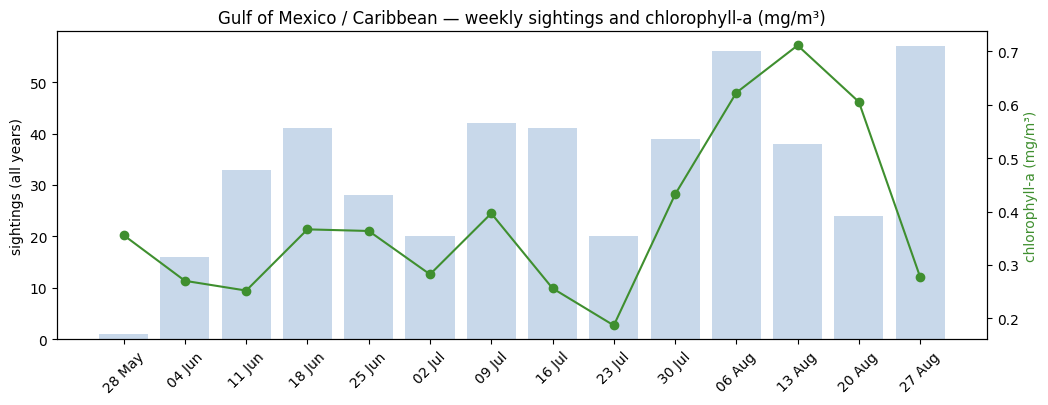

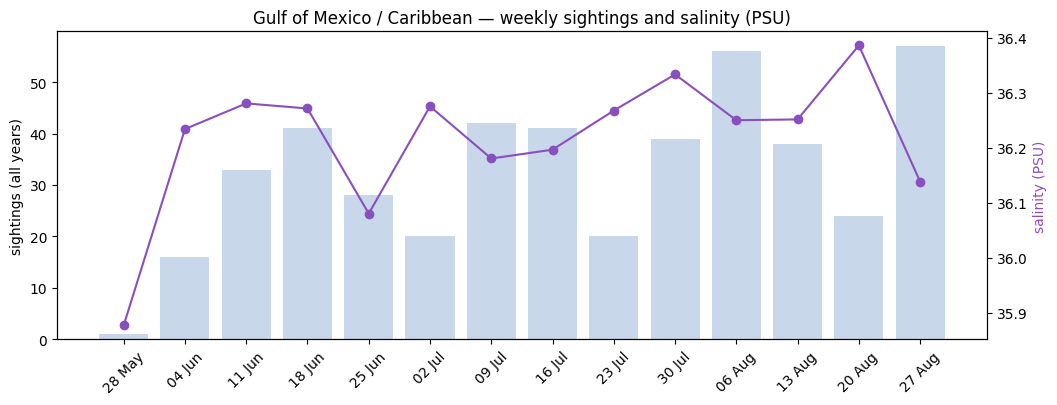

In [42]:
season_env_profile(peak['Gulf of Mexico / Caribbean'], 'Gulf of Mexico / Caribbean', 'sst_cmems', 'SST (°C)')
season_env_profile(peak['Gulf of Mexico / Caribbean'], 'Gulf of Mexico / Caribbean', 'chl_cmems', 'chlorophyll-a (mg/m³)', color="#3f8f2f")
season_env_profile(peak['Gulf of Mexico / Caribbean'], 'Gulf of Mexico / Caribbean', 'sss_cmems', 'salinity (PSU)', color="#8a4fbf")

**SST:** No visible patterns

**Chlorophyll-a:** Low during the season then peak near the end (weak pattern)

**SSS:** No visible patterns

#### Annual Climatology

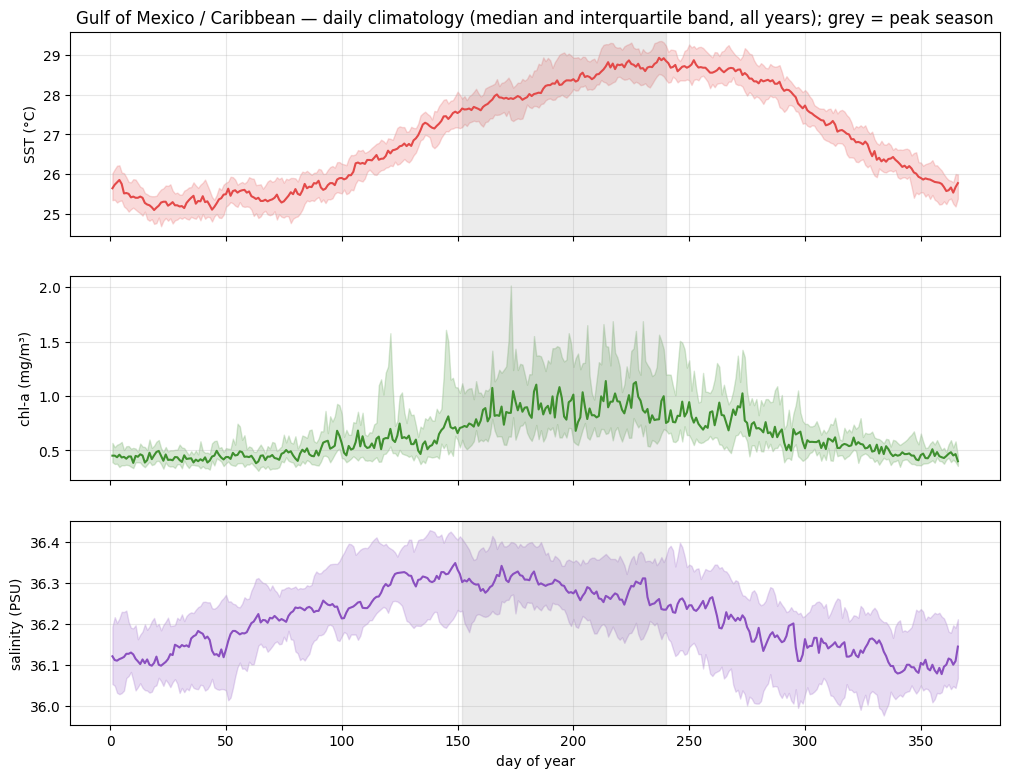

In [43]:
annual_profile(s)

#### Days with vs without sightings (anomalies from the daily climatology, peak season only)

In [44]:
anomaly_table(s)

sst_anom        chl_anom        sss_anom        n_days
                           mean    std     mean    std     mean    std       
days without sightings    0.038  0.627    0.255  1.057    0.005  0.121   3893
days with sightings       0.399  0.636    0.407  1.370    0.009  0.129    247

#### Season by Season

In [45]:
season_by_year(s)

,year,sightings,peak_doy,sst,chl,sss
0,2002,11,236,28.46,0.85,36.17
1,2003,2,221,28.16,1.63,36.25
2,2004,27,222,28.72,2.24,36.28
3,2005,35,175,28.70,0.64,36.18
4,2006,40,174,28.55,0.88,36.22
5,2007,17,238,28.65,0.96,36.17
6,2008,52,241,28.33,1.37,36.18
7,2009,93,160,28.46,1.44,36.20
8,2010,10,216,28.49,1.51,36.23
9,2011,4,165,28.53,1.45,36.17


#### Timing of the peak vs season conditions

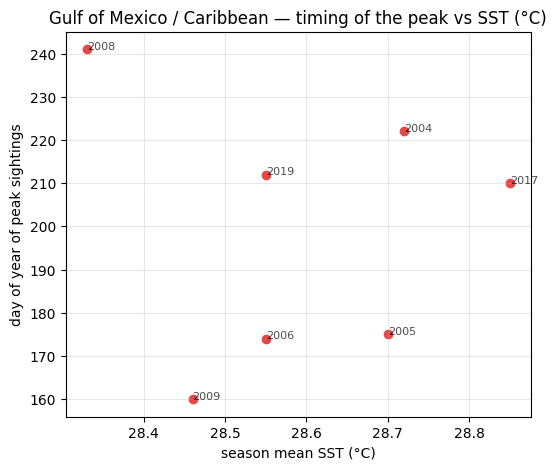

correlation: -0.07 | years: 7


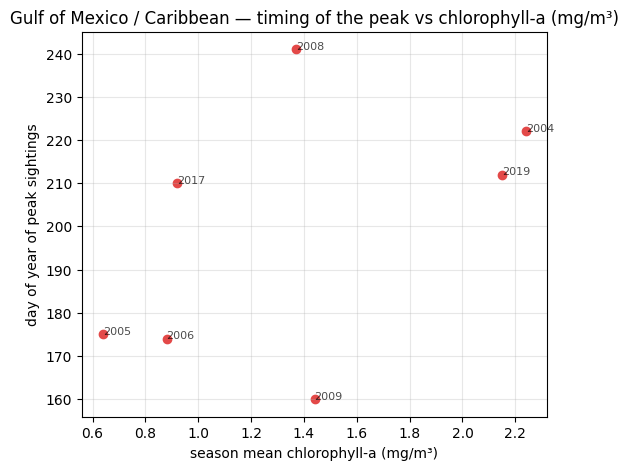

correlation: 0.47 | years: 7


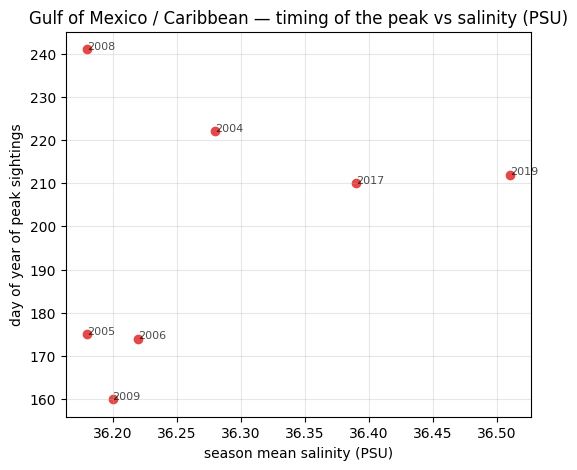

correlation: 0.31 | years: 7


In [46]:
for var, lab in [('sst', 'SST (°C)'), ('chl', 'chlorophyll-a (mg/m³)'), ('sss', 'salinity (PSU)')]:
    peak_vs_var(s, var, lab)

## Step 5 – Comparison of the three sites